In [ ]:
import warnings

# Жорсткі сістэмны бан на любыя папярэджанні ад бібліятэкі LightGBM
warnings.filterwarnings("ignore", module="lightgbm.*")
warnings.filterwarnings("ignore", message=".*eval_set.*")

# from sklearn.exceptions import ConvergenceWarning
# # Жорстка прыглушаем ConvergenceWarning для ўсяго Python-працэсу
# warnings.filterwarnings("ignore", category=ConvergenceWarning)



"""import warnings
# Глушым тэхнічныя папярэджанні ад scikit-learn
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
# Гэты радок цалкам адключае MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ВЫПРАЎЛЕНА: Глушым абсалютна любыя варнінгі (і UserWarning, і DeprecationWarning), якія ідуць з модуля lightgbm
warnings.filterwarnings("ignore", module="lightgbm")"""

'import warnings\n# Глушым тэхнічныя папярэджанні ад scikit-learn\nwarnings.filterwarnings("ignore", category=UserWarning, module="sklearn")\n# Гэты радок цалкам адключае MatplotlibDeprecationWarning\nwarnings.filterwarnings("ignore", category=DeprecationWarning)\n\n# ВЫПРАЎЛЕНА: Глушым абсалютна любыя варнінгі (і UserWarning, і DeprecationWarning), якія ідуць з модуля lightgbm\nwarnings.filterwarnings("ignore", module="lightgbm")'

In [16]:
import gc
import matplotlib.pyplot as plt
import sys

import numpy as np
from pathlib import Path

from IPython.display import Image, display


from modules import (
    BayesianTuner,
    ClassifierBench,
    DataVisualizer,
    ModelEvaluator,
    PrepareDataset,    
)
    

ROOT = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd() # рашэнне для .ipny  і .py
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

DATA = ROOT / "data"
OUT = ROOT / "output"
OUT.mkdir(parents=True, exist_ok=True)

evaluator = ModelEvaluator()
bench = ClassifierBench()
viz = DataVisualizer(OUT)
dataset = PrepareDataset(DATA)

## 1. Датасет Online Shoppers Purchasing Intention

In [17]:
   
file_name="online_shoppers_intention.csv"

frame = dataset.load_csv(file_name=file_name)
frame.head(2)

print(f"Крыніца даных: {DATA/file_name}")


[LoadDataset] online_shoppers_intention.csv: 12330 радкоў x 18 слупкоў
Крыніца даных: d:\DScourse\hw4\data\online_shoppers_intention.csv


## 2. Падрыхтоўка даных
Падзел спосабам 'static_3way' (60/20/20), падзел пад CV+holdout  
Вызначэнне правіл маштабавання

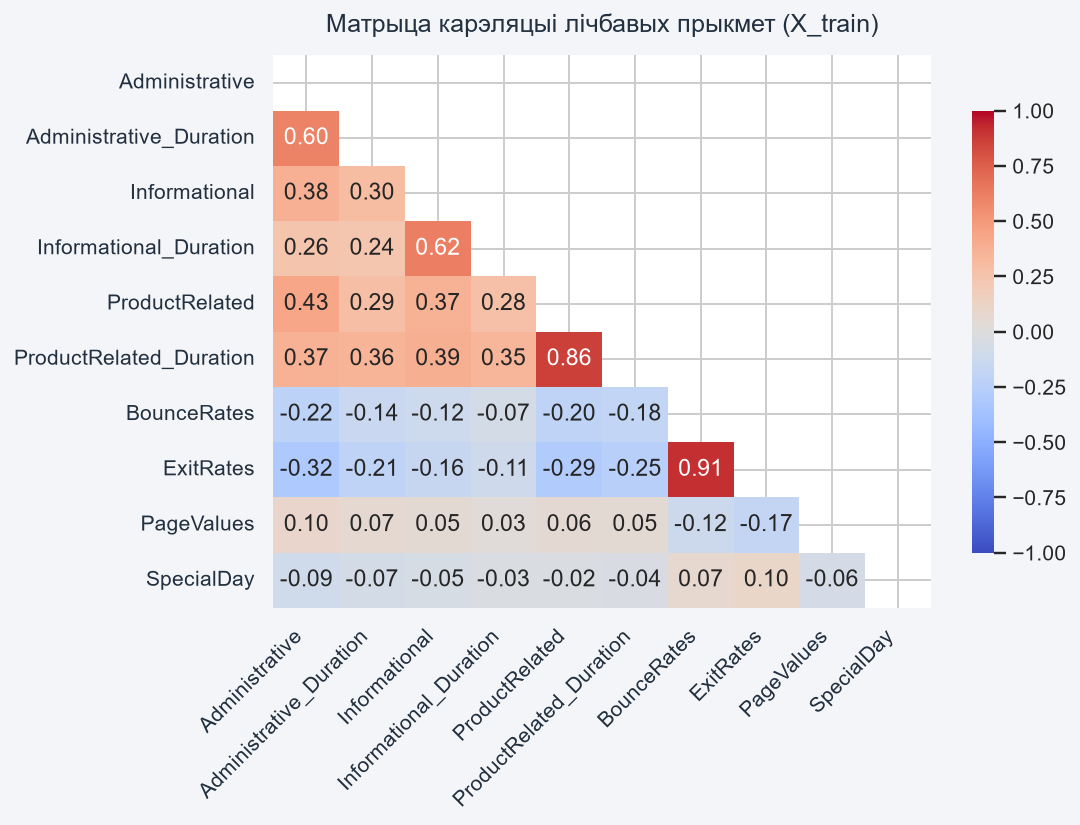

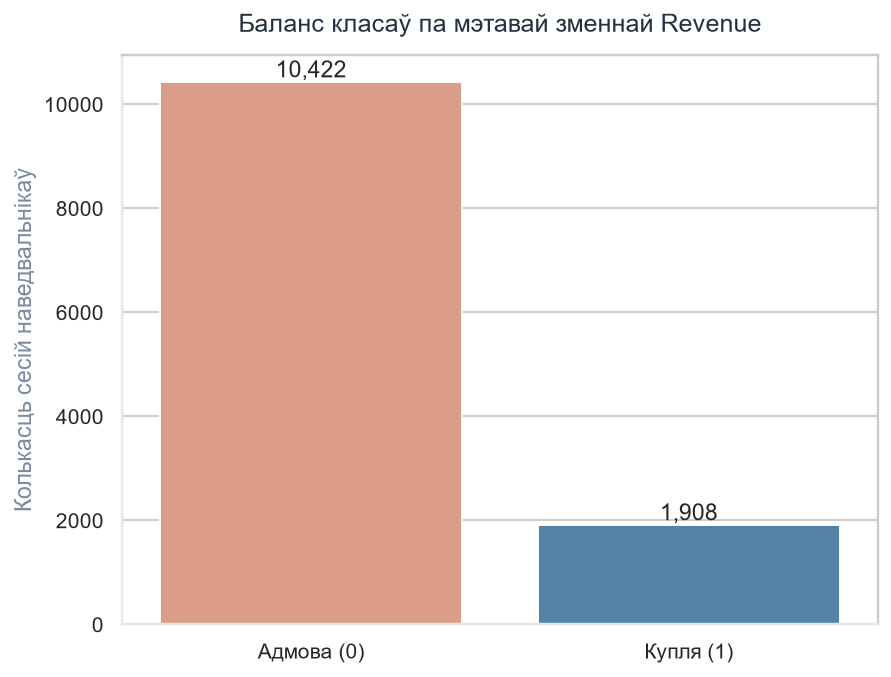

[PrepareDataset] Колькасць радкоў у даных 12330, з іх
(Купля: 1908 (Revenue==1), што склала (15.474%), 
(Адмова: 10422 (Revenue==0)
[PrepareDataset] Падзел static_3way (60/20/20): train=7398, val=2466, test=2466
               Размеркаванне (Revenue==1) па выбарках: train = 1145, val=381, test=382
[PrepareDataset] Падзел пад СV + hold out: CV=9864, test=2466
               Размеркаванне (Revenue==1) па выбарках: СV = 1526, test=382
[PrepareDataset] Даныя не масштабаваліся на этапе падзелу выбаркі
[Classifier] Метады:
  Dummy Classifier — baseline
  LogisticRegression — лінейная
  SVM — лінейная
  KNN — простае дрэва
  DecisionTree — простае дрэва
  ExtraTrees   — бэггінг
  LightGBM, XGBoost — бустынг
[Classifier] Маштабаванне вагі станоўчага класа: scale_pos_weight=5.5. Перадаю параметрам для XGBoost


In [18]:

target_name = "Revenue"
# Будуем матрыцу карэляцыі для ўсіх прыкмет, выключыўшы таргет "Revenue"
plot_CM = viz.plot_correlation_matrix(x_train=frame.iloc[:, :-1], filename="corr_matrix_engin_feat.png")
display(Image(filename=plot_CM))

ohe_feature_list = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
known_categories = {
    col: sorted(list(frame[col].dropna().unique())) for col in ohe_feature_list
}

plots_list = []
plot_path = viz.plot_class_balance(frame[target_name], name=target_name)
plots_list.append(plot_path)
display(Image(filename=plot_path))

split = dataset.prepare(frame, target_name = target_name, test_size = 0.2, val_size = 0.2, random_state=42)   

bench.build(split.y_train)

bench.preprocessor = dataset.create_preprocessor(categories_dict=known_categories)

Высновы:
 * 2.1 Умераны дысбаланс класаў: 15%
 * 2.2 Моцна скарэляваныя прыкметы:  
        0.91 паміж парай Bounce Rates (паказчык адмоваў) і Exit Rates (паказчык выхаду). Exit Rates - больш інфарматыўная для мадэлі
        0.84 паміж ProductRelated (колькасць прагледжаных старонак з таварамі за сесію) і ProductRelated_Duration (агульны час, праведзены на гэтых старонках). ProductRelated_Duration - утрымлівае анамальна высокія значэнні
 * 2.3 Датасэт змяшчае лічбавыя і катэгарыяльныя прыкметы, што вымагае маштабавання паводле прыроды метаду класіфікацыі       

Рашэнне:
 * 2.1 збудуем архітэктуру вакол тэмы дысбалансу і даследуем паводзіны класіфіктараў  
 * 2.2 Пакінем прыкметы ў поўным аб'еме у невялікім датасэце, зробім акцэнт на класіфікацыі ансамблевымі метадамі (ExtraTrees, XGBoost, LightGBM)
На лінейныя мадэлі і простыя дрэвы паглядзім для забаўкі.
 * 2.3 Вызначылі матэматычны скалер паводле прыроды сямействаў мадэлей
        Dummy - не патрабуе маштабавання.
        Для лічбавых прыкмет   
            LogisticRegression - StandardScaler()  
            KNN, SVM - RobustScaler()  
            DecisionTree, ExtraTrees, LightGBM, XGBoost - маштабавання лічбавых прыкмет не патрабуюць   
        Для катэгарыяльных прыкмет у залежнасці ад тыпу:        
            OneHotEncoder() - тэкставыя катэгорыі, лічбавыя катэгорыі (інтэрпрэтуем як катэгорыі, не лікі)  
            OrdinalEncoder() - скарысталі для прыкметы "Month" з указаннем парадку следвання месяцаў і з улікам асаблівасці напісання ('June')  
                months_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']  
            Бінарныя прыкметы пакінулі без змен        

Адкінутае для дэманстрацыі рашэнне:  
Зменім прыкметы, што дазволіць класіфікаваць усімі тыпамі метадаў  
1. Стварэнне адноснай метрыкі  
  Avg_Time_Per_Product = ProductRelated_Duration / "ProductRelated" + 1e-5  
2. Спіс калонак для выдалення (высокая карэляцыя 0.91 і 0.84)  
  columns_to_drop = ["BounceRates", "ProductRelated_Duration"]  
Вынікі: лінейныя алгарытмы і дрэвы працуюць добра, але па Сцюдэнту перамагае LightGBM    
Матрыца памылак на тэсце: 1822 | 262  
                            71 | 311  


## 3. Класіфікацыя на падзеле (60/20/20)

In [19]:
metrics_table = bench.evaluate_baseline_models(
        split=split,        
        evaluator=evaluator,
        random_state=42
    )
print("\n Параўноўчая табліца метрык для падзелу 60/20/20 ")
print(metrics_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

--- Запуск Dummy у якасці baseline ---
Маштабаванне прыкмет Dummy не патрабуе
--- Запуск Logistic Regression ---
Маштабаванне прыкмет абавязковае
--- Запуск SVM ---
Маштабаванне прыкмет абавязковае (Robust + Calibrated Config)
--- Запуск KNN ---
Маштабаванне прыкмет абавязковае (Robust + Calibrated Config)
--- Запуск Дрэва рашэнняў ---
Маштабаванне катэгарыяльных прыкмет абавязковае (Balanced + Raw Numeric)
--- Запускаем ансамбль ExtraTrees ---
Маштабаванне катэгарыяльных прыкмет абавязковае (Balanced + Raw Numeric)

 Параўноўчая табліца метрык для падзелу 60/20/20 
                               Мадэль  PR-AUC  ROC-AUC  Precision  Recall     F1     F2  Accuracy  Час (сек)
           DummyClassifier (Baseline)  0.1548   0.5013     0.1567  0.1575 0.1571 0.1573    0.7388     0.0046
       Logistic Regression (Balanced)  0.6706   0.9027     0.5259  0.7717 0.6255 0.7057    0.8573     0.2546
     SVM (Robust + Calibrated Config)  0.6731   0.9034     0.7337  0.3832 0.5034 0.4237    0.8832   

### 📊 Аналітычныя высновы на статычным падзеле (60/20/20)

* **DecisionTree (Balanced):** Абсалютны лідар па **F1 (0.6816)** і **F2 (0.7672)**. Мадэль знайшла **83.73%** усіх рэальных пакупнікоў (`Recall`) пры сярэдняй дакладнасці прагнозу (`Precision = 0.57`). Гэта найлепшы выбар для максімізацыі прыбытку і ахопу аўдыторыі.

* **Logistic Regression:** Паказвае стабільны і збалансаваны вынік (PR-AUC = 0.6706, F1 = 0.6255) при добрым ахопе пакупнікоў (`Recall = 0.7717`). Галоўная перавага — высокая хуткасць навучання (**0.47 сек**).

* **ExtraTrees (Ensemble):** Лепшы паказчык па **PR-AUC (0.6778)** і **Precision (0.7976)**. Прагноз пакупкі спраўджваецца з імавернасцю ~80%, што робіць мадэль ідэальнай для эканоміі маркетынгавага бюджэту (ацэнка персанальных зніжак). Аднак мае нізкі `Recall` (35.17%) і патрабуе больш часу (**1.84 сек**).

* **SVM (Robust):** Паказаў высокую дакладнасць (`Precision = 0.73`) і добрую хуткасць (**0.35 сек**), але мае нізкі ахоп (`Recall = 0.3832`), цалкам дублюючы хібы ExtraTrees.

* **KNN (Distance):** Галоўны аўтсайдар (PR-AUC = 0.5972). Паказаў **катастрафічна доўгі час працы — 17.44 сек** (у 40 разоў павольней за іншыя метады)

📌 **Фінальнае рашэнне:** Мадэлі **DecisionTree, LogisticRegression і ExtraTrees** пакідаем да далейшага разгляду на крос-валідацыі. Мадэлі SVM і KNN адхіляем з-за нізкай эфектыўнасці і нізкай прадукцыйнасці KNN.

## 4. Класіфікацыя на Крос-Валідацыі праз StratifiedKFold(5)

In [29]:
CV_methods_names = ["LogisticRegression", "DecisionTree", "ExtraTrees", "LightGBM", "XGBoost"]
CV_configs = bench.prepare_final_models(models_to_keep=CV_methods_names)
    
fold_pr2, fold_roc2, oof_predictions = bench.cross_validate_newV(split.x_cv, split.y_cv, models_conf=CV_configs)

# табліца метрык PR i ROC
cv_metrics_table = bench.get_metrics_table()
print("\n[Cross-Validation] Табліца метрык PR i ROC на StratifiedKFold(5), адсартавана па метрыцы выбару PR-AUC:")
print(cv_metrics_table.to_string(index=False))

best_threshold, best_score = evaluator.optimize_threshold_for_fbeta(            
            y_true=split.y_cv, 
            oof_probas=oof_predictions["LightGBM"], 
            model_name="LightGBM",
            beta=2.0
        )

df_base_report = evaluator.compile_performance_report(
    y_true=split.y_cv, 
    probas_dict=oof_predictions, 
    threshold=best_threshold #0.20
)
print(df_base_report.to_string(index=False))

[Cross-Validation] LogisticRegression ...
     PR-AUC=0.6506 ± 0.0200
[Cross-Validation] DecisionTree ...
     PR-AUC=0.6549 ± 0.0187
[Cross-Validation] ExtraTrees ...
     PR-AUC=0.6830 ± 0.0128
[Cross-Validation] LightGBM ...
     PR-AUC=0.7512 ± 0.0181
[Cross-Validation] XGBoost ...
     PR-AUC=0.7504 ± 0.0170

[Cross-Validation] Табліца метрык PR i ROC на StratifiedKFold(5), адсартавана па метрыцы выбару PR-AUC:
             model PR-AUC (Mean ± STD) ROC-AUC (Mean ± STD)
          LightGBM     0.7512 ± 0.0181      0.9340 ± 0.0039
           XGBoost     0.7504 ± 0.0170      0.9332 ± 0.0037
        ExtraTrees     0.6830 ± 0.0128      0.9029 ± 0.0070
      DecisionTree     0.6549 ± 0.0187      0.9167 ± 0.0034
LogisticRegression     0.6506 ± 0.0200      0.9002 ± 0.0069

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.410 (Валідацыйны F2: 0.7632)
            Мадэль   PR-AUC  ROC-AUC  Precision   Recall       F1       F2  Acc

### Аналітычныя высновы па выніках крос-валідацыі і аптымізацыі парога

* **Перавага градыентнага бустынгу (LightGBM і XGBoost):** Мадэлі на аснове градыентнага бустынгу паказалі найвышэйшую якасць, забяспечыўшы ўзровень **PR-AUC ~0.75**. **LightGBM** займае першае месца ў рэйтынгу (PR-AUC = 0.7512, ROC-AUC = 0.9340) і дэманструе нізкую дысперсію метрык па фолдах (STD ±0.0181). **XGBoost** ідзе ўшчыльную (PR-AUC = 0.7504) — розніца паміж імі статыстычна неістотная.

* **Асаблівасці ансамбля ExtraTrees:** дэманструе найвышэйшую дакладнасць (**Precision = 0.7122**) сярод усіх алгарытмаў. Мінімізуе колькасць памылковых спрацоўванняў (False Positives), аднак мае нізкую поўнату прагнозу (`Recall` = 0.4849). Гэты метад мэтазгодна выкарыстоўваць у маркетынгавых кампаніях з высокім коштам аднаго кантакту, дзе крытычна важная дакладнасць лакалізацыі мэтавай групы.

* **Падзенне эфектыўнасці DecisionTree і Logistic Regression:** На этапе крос-валідацыі дадзеныя мадэлі саступілі бустынгу. Хоць зніжэнне працоўнага парога дазволіла павялічыць іх поўнату (`Recall` да 82–86%), узровень дакладнасці (`Precision`) пры гэтым знізіўся. 

* **Нізкая эфектыўнасць KNN і SVM:** Метрычны **KNN** забяспечыў нізкую якасць падзелу (PR-AUC = 0.5827) пры значных часавых затратах. Класічны **SVM** паказаў найгоршую прадукцыйнасць (PR-AUC = 0.5137) і высокую нестабільнасць па фолдах (STD ±0.0613).

* **Эфект аптымізацыі працоўнага парога (F2-Score):** Усталяванне аптымальнага парога на ўзроўні **0.410** для LightGBM дазволіла зрушыць баланс мадэлі ў бок павелічэння поўнаты. Выніковы **F2-Score склаў 0.7632**. Мадэль паспяхова ідэнтыфікуе **88.07% рэальных пакупнікоў** (`Recall`), захоўваючы дакладнасць (`Precision`) на ўзроўні 49.75%.

📌 **Фінальнае рашэнне:** Для разгортвання і далейшай працы абіраецца мадэль **LightGBM з рабочым парогам 0.410**, бо яна забяспечвае максімальную поўнату ахопу мэтавай аўдыторыі пры захаванні стабільнасці прагнозу.


Візуалізацыя вынікаў класіфікацыі на кроку крос-валідацыі

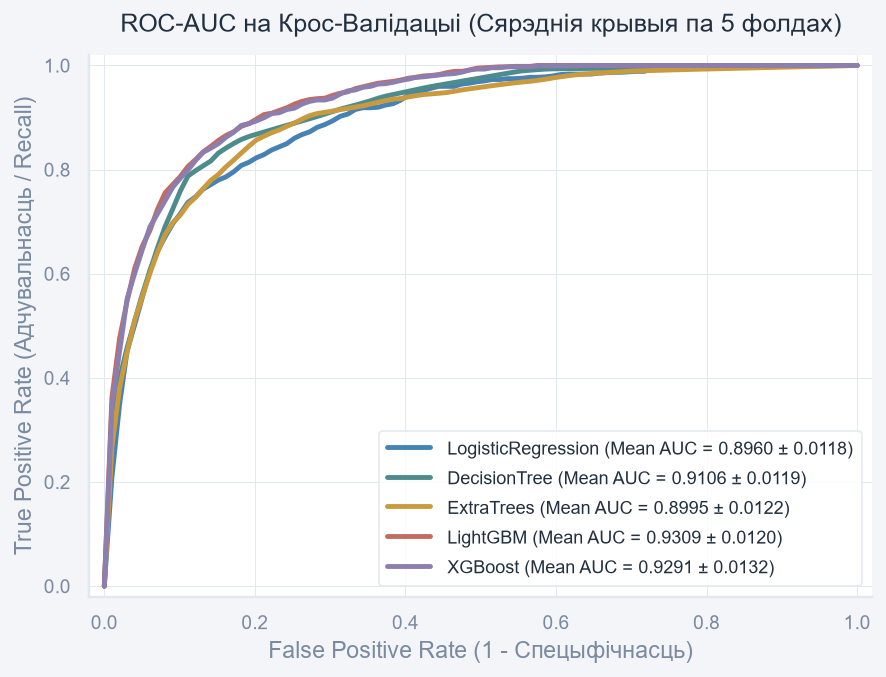

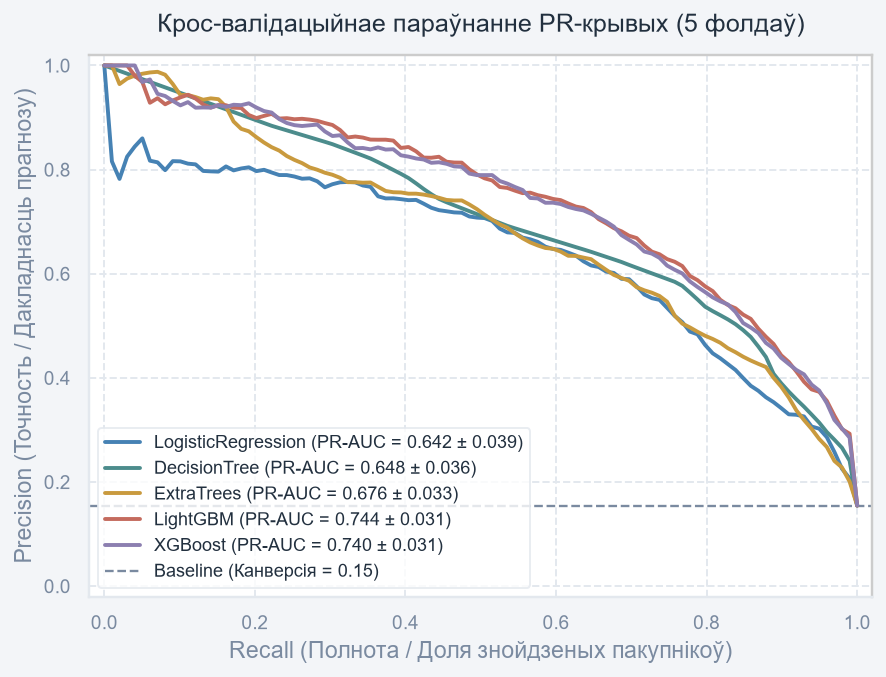

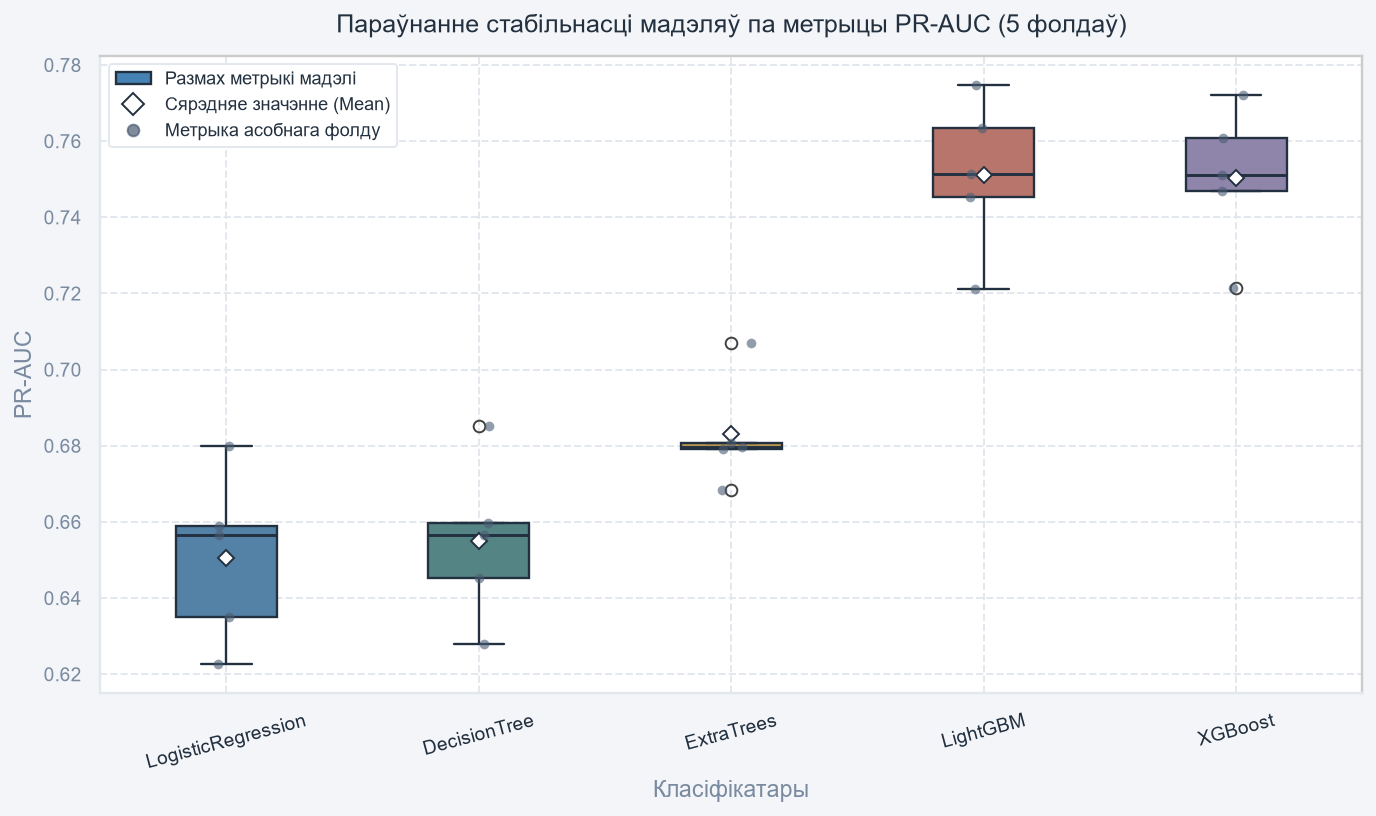

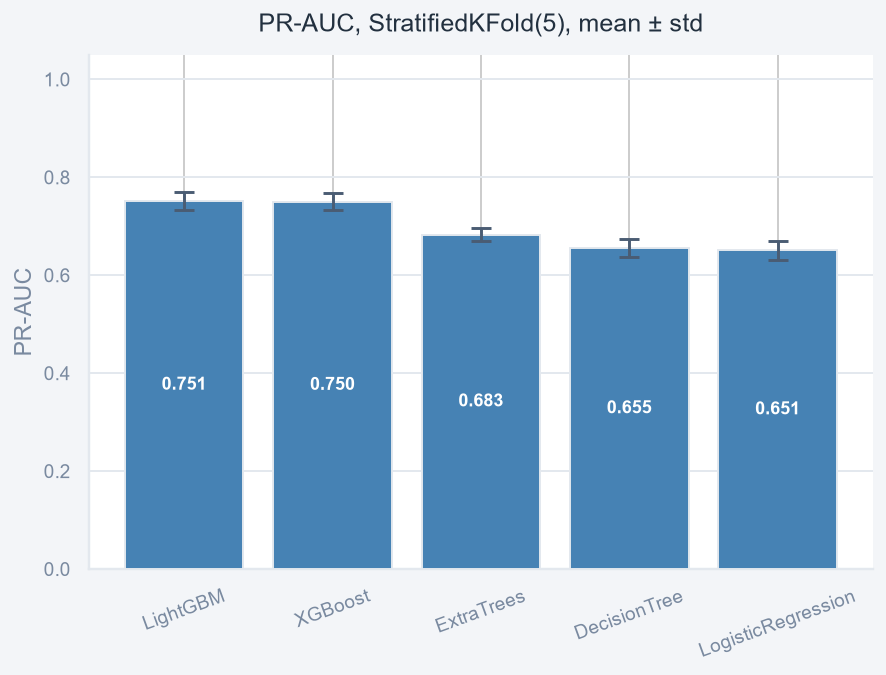

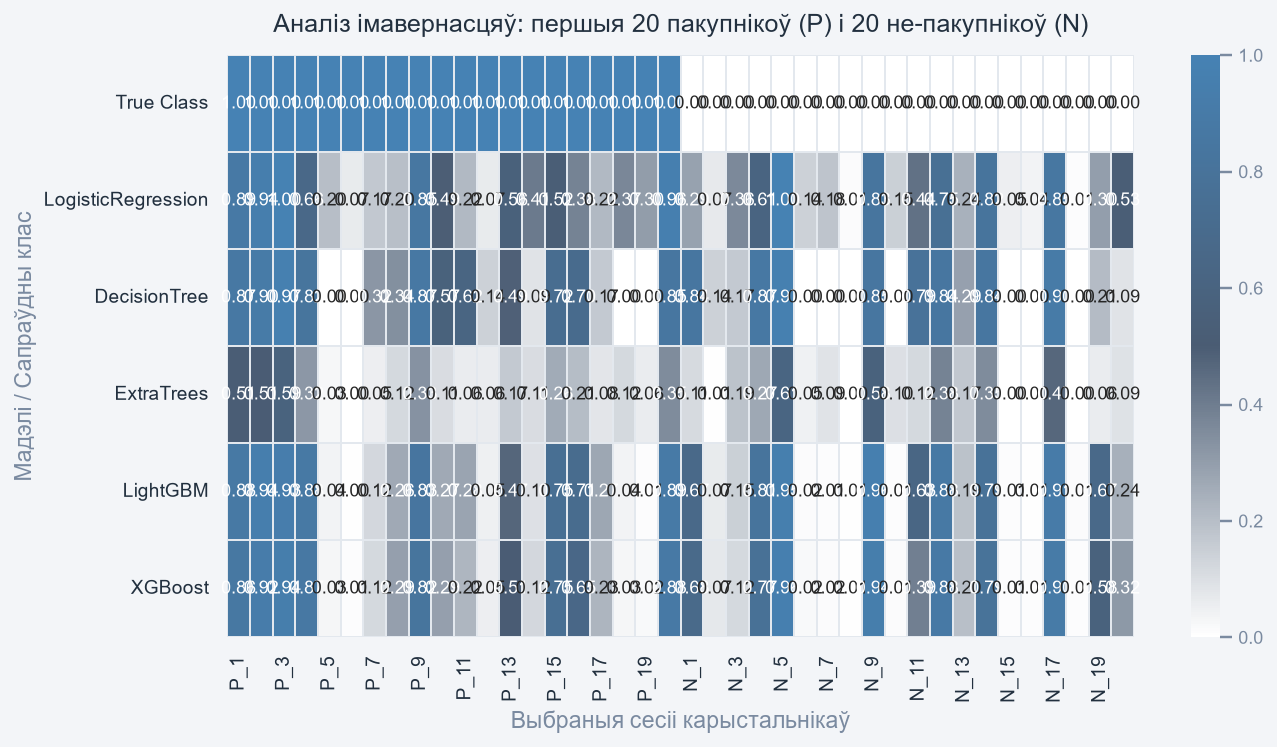


[Cross-Validation] Графік ранняга прыпынку па фолдах для бустынгаў


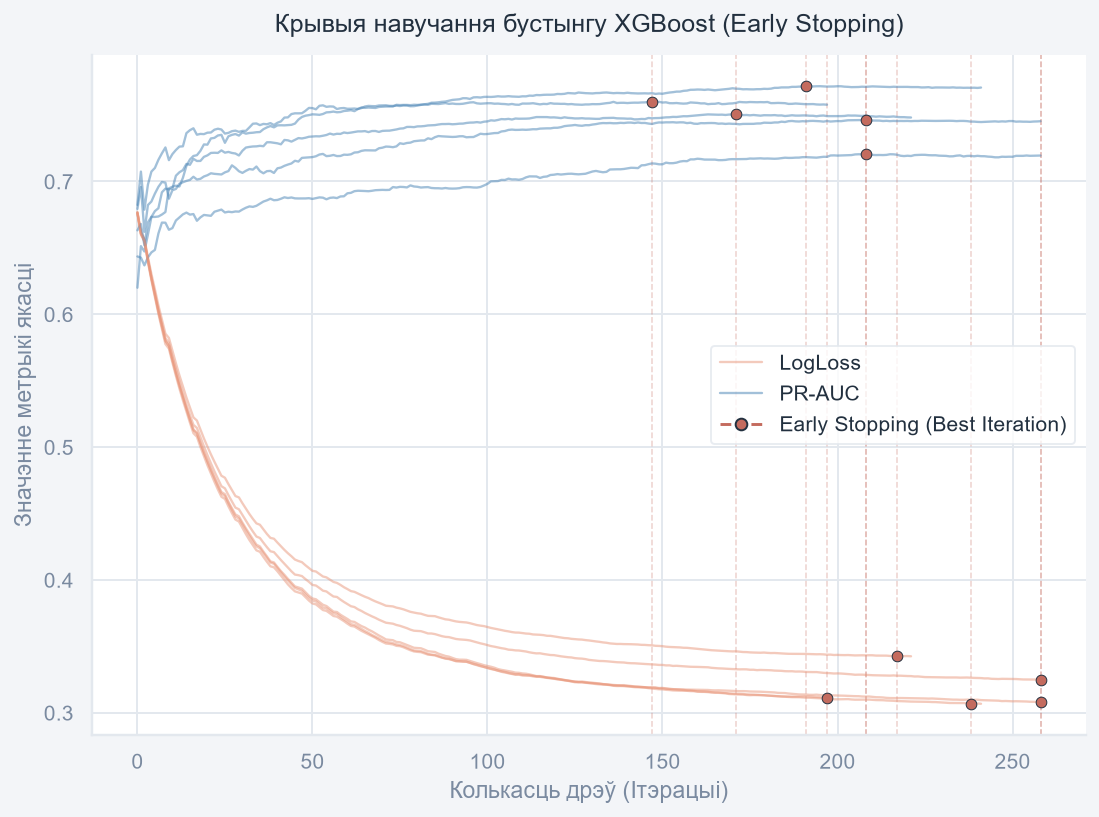


[Cross-Validation] Графік Train vs Validation для бустынгаў


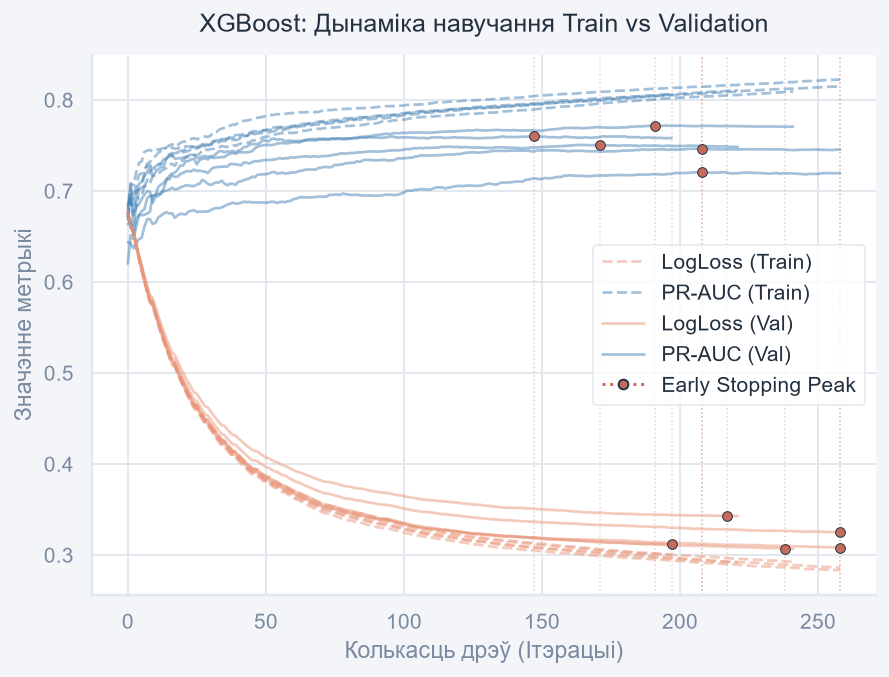

60986

In [31]:
roc_plot_path = viz.plot_roc_curve_cv(x=split.x_train, y=split.y_train, models_dict=CV_configs, preprocessor=bench.preprocessor)    
display(Image(filename=roc_plot_path))

pr_curve_plot = viz.plot_pr_curve_cv(x=split.x_train, y=split.y_train, models_dict=CV_configs, preprocessor=bench.preprocessor)
display(Image(filename=pr_curve_plot))
    
boxplot = viz.plot_models_boxplot(fold_pr2, metric_name="PR-AUC", filename="models_stability_pr_auc.png")
display(Image(filename=boxplot))

cv_table = evaluator.cv_table(fold_pr2, fold_roc2)
cv_pr_auc = viz.plot_cv_pr_auc(cv_table)
display(Image(filename=cv_pr_auc))

path_heat = viz.plot_predictions_comparison(y_true=np.asarray(split.y_train), preds_dict=oof_predictions, num_samples_per_class=20)
display(Image(filename=path_heat))
    
if bench.cv_evals_results:
    for model_name, evals_data in bench.cv_evals_results.items():
        path_early_stopping = viz.plot_boosting_early_stopping(evals_result=evals_data, filename=f"{model_name.lower()}_cv_early_stopping.png")
        path_train_vs_val = viz.plot_boosting_train_vs_val(evals_result=evals_data, filename=f"{model_name.lower()}_train_vs_val.png")
        
    print("\n[Cross-Validation] Графік ранняга прыпынку па фолдах для бустынгаў")
    display(Image(filename=path_early_stopping))
    print("\n[Cross-Validation] Графік Train vs Validation для бустынгаў")
    display(Image(filename=path_train_vs_val))


plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку
    

# 4.2 Выбар мадэлі па парным t-тэсце Сцюдэнта


[Evaluator] Парны t-тэст Сцюдэнта па фолдах: LightGBM vs XGBoost
t-статыстыка=0.951, p-value=0.3953
Парогавае значэнне t-статыстыкі = 2.776 - гэта мінімальны парог для t, які трэба перасягнуць, каб перастаць лічыць розніцу выпадковай
[Evaluator] У распрацоўку: LightGBM. 
 (p-value (0.3953) >= 0.05) Розніца НЕ значная паміж метадамі (t-статыстыка < 2.776 )


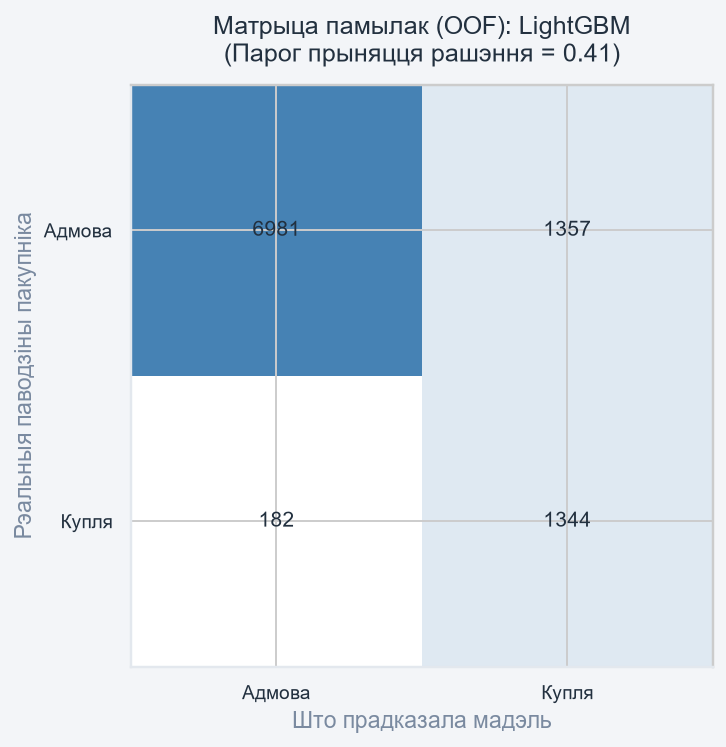

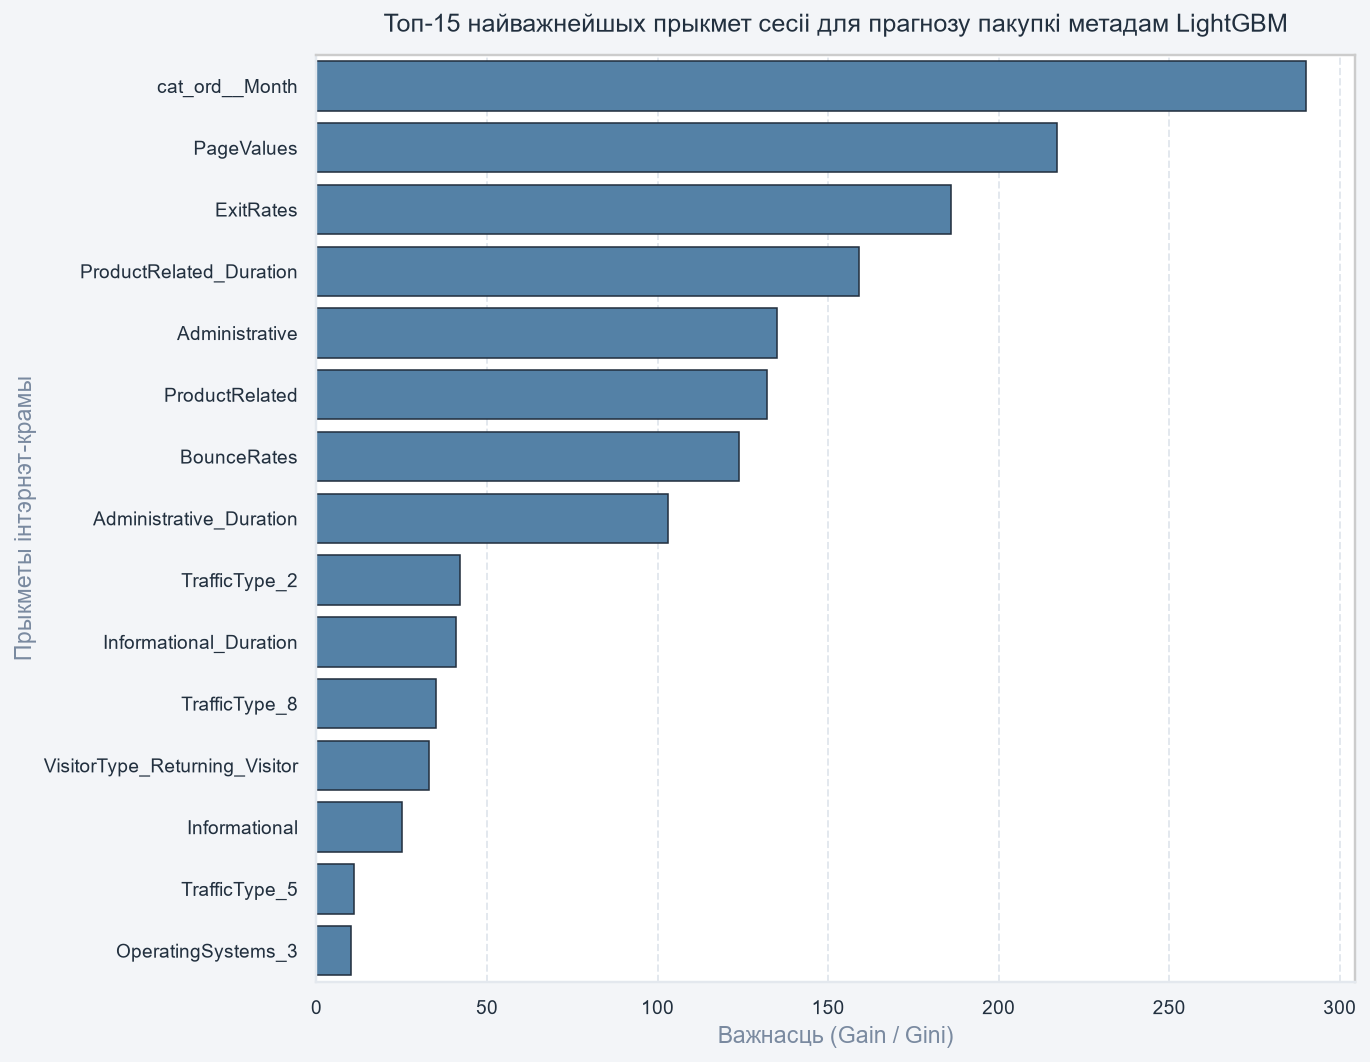

In [32]:
    # Выбар паміж двума лепшымі па PR
best_name = evaluator.pick_best(fold_pr2)   
    
    # Матрыца памылак для выбранай топ-мадэлі па яе імені карыстаецца гатовым вектарам імавернасцяў OOF
cm_path = viz.plot_classification_results(
    #y_true=split.y_cv, 
    y_true=split.y_cv.to_numpy(),
    y_probas=oof_predictions[best_name], 
    model_name=best_name,
    threshold=best_threshold,#0.20, # наладжваем парог пад нашы 15% канверсіі
    filename=f"confusion_matrix_{best_name}.png"
)
display(Image(filename=cm_path))

importance_path = viz.plot_feature_importance(model_pipeline=bench.fitted[best_name], model_name=best_name, filename=f"feature_importance_{best_name}.png")
display(Image(filename=importance_path))

Высновы


### 4.3 Learning curves. Эфектыўнасць выкарыстання дадзеных
Праверка на перанавучанне метадаў. Залежнасць train/val score ад памеру выбаркі

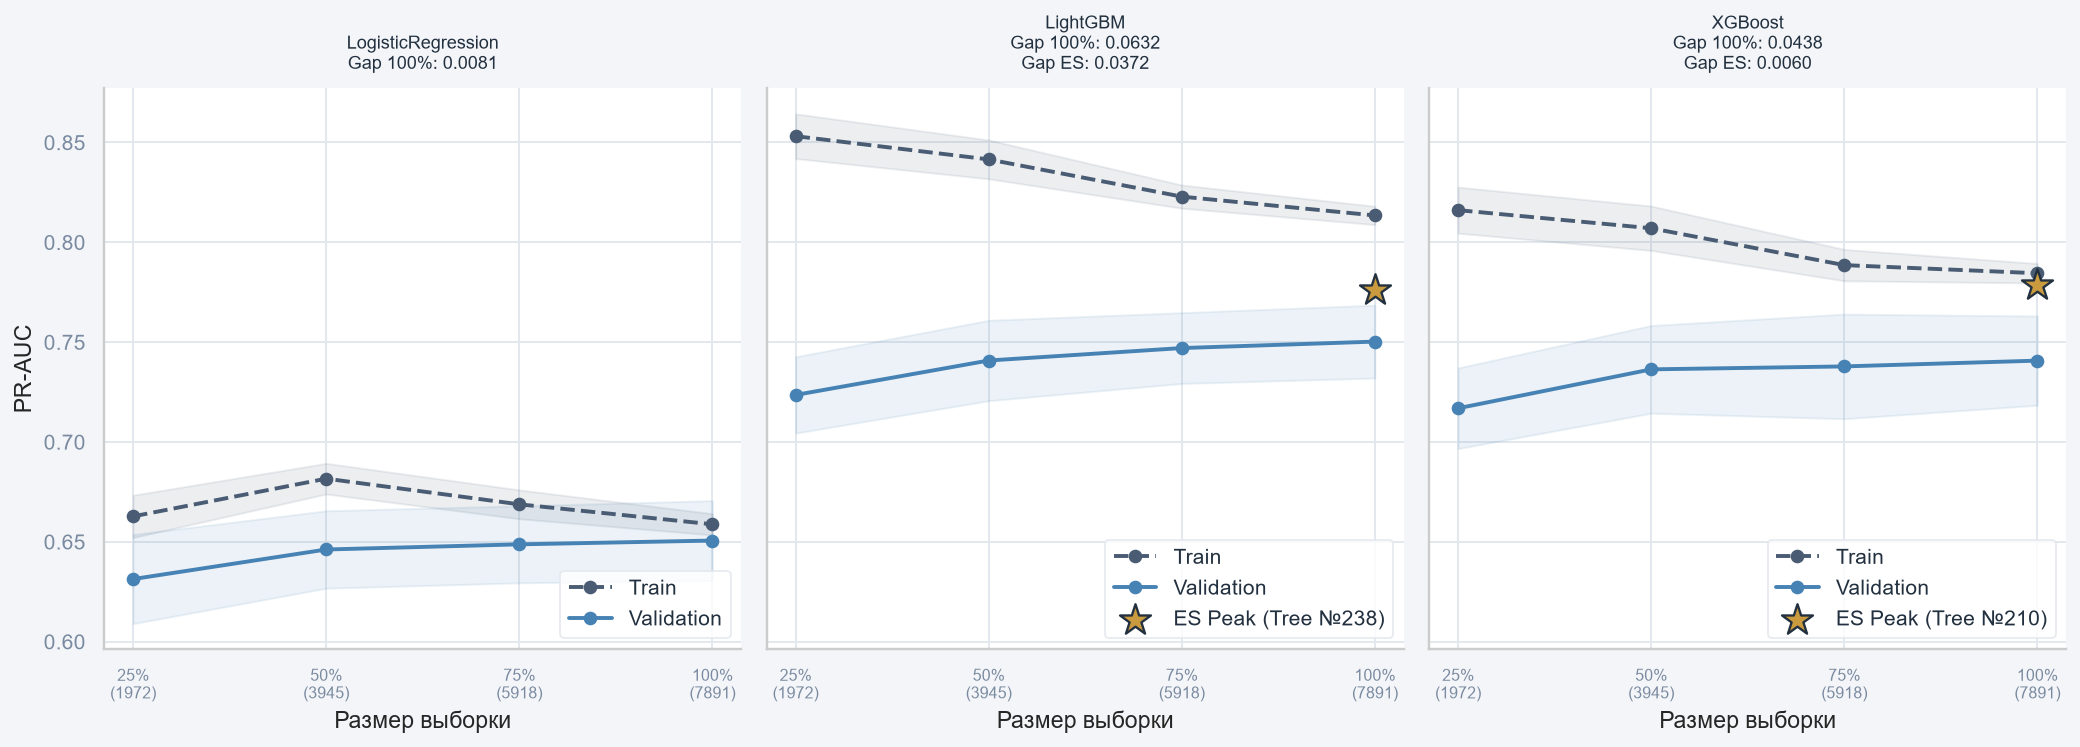

Параўнальны аналіз перанавучання (БЕЗ Early Stopping vs з улікам Early Stopping).
Высновы (ацэнка gap) па Early Stopping, калі ён мае месца быць, іначай напрыканцы кросвалідацыі на 100% (7891) даных, вылучаных пад яе
            Мадэль Gap 100% (Без EarlStop) Gap EarlStop (Працоўны) Кропка прыпынку                          Высновы
           XGBoost                  0.0438                  0.0060      Дрэва №210 ✓ Стабільная мадэль (gap < 0.05)
          LightGBM                  0.0632                  0.0372      Дрэва №238 ✓ Стабільная мадэль (gap < 0.05)
LogisticRegression                  0.0081                       -       Не выкар. ✓ Стабільная мадэль (gap < 0.05)


14102

In [ ]:
LC_methods_names = ["LogisticRegression", "LightGBM", "XGBoost"]
    
learning_curves_data_ES = bench.collect_learning_curves_ES(split.x_cv, split.y_cv, LC_methods_names)
        
path_es = viz.plot_learning_curves_ES(learning_curves_data_ES, filename="models_learning_curves_ES.png")
display(Image(filename=path_es))
        
print("Параўнальны аналіз перанавучання (БЕЗ Early Stopping vs з улікам Early Stopping).")
print("Высновы (ацэнка gap) па Early Stopping, калі ён мае месца быць, іначай напрыканцы кросвалідацыі на 100% (7891) даных, вылучаных пад яе")
                
df_comparison = bench.analyze_learning_gaps_table(learning_curves_data_ES)
print(df_comparison.to_string(index=False))
    
plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку

ВЫсновы: галодныя да дадзеных

### 6.2 Валідацыйныя крывыя. Аптымізацыя LightGBM і аналіз перанавучання

[ClassifierBench] Крос-валідацыя LightGBM па параметру 'num_leaves'...


d:\DScourse\hw4\modules\visualization.py:53: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.tight_layout()
d:\DScourse\hw4\modules\visualization.py:54: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(path, dpi=140, bbox_inches="tight")


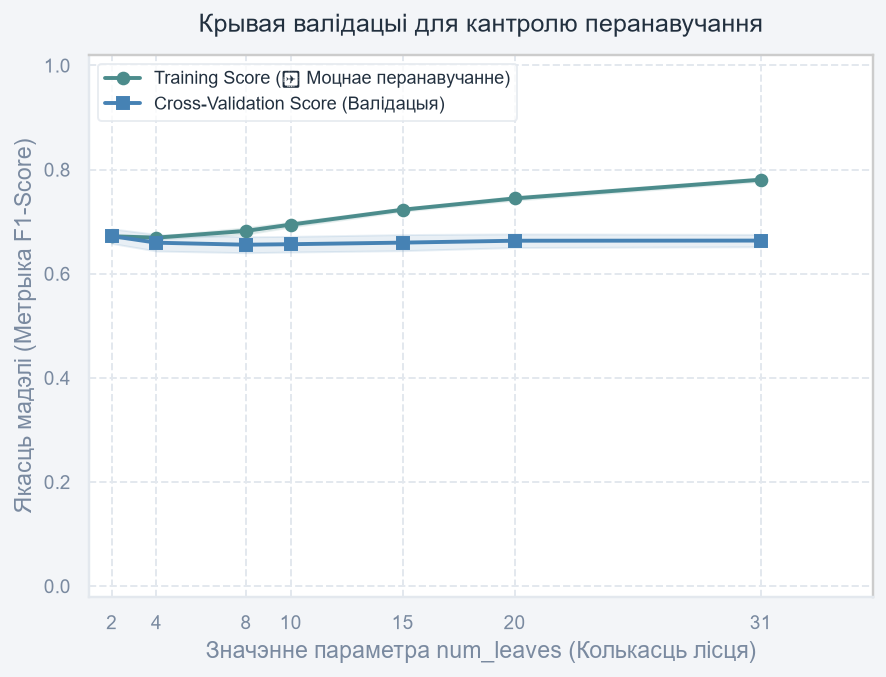

In [37]:
leaves_range = [2, 4, 8, 10, 15, 20, 31]
    
    # Вылічэнне ў модулі класіфікатара
lgbm_results = bench.collect_lgbm_validation_curves(
    x=split.x_cv,  # Перадаем прыкметы для CV
    y=split.y_cv,  # Перадаем таргет для CV
    param_name="num_leaves",
    param_range=leaves_range,
    base_params={"max_depth": -1}  # Дазваляем лісцю расці #     base_params={}  # - перазапісаць дэфолтны значэнне параметру мадэлі
)
    
val_curve_path = viz.plot_validation_curve(curves_results=lgbm_results, model_name="LightGBM", filename="lgbm_leaves_curve.png")
display(Image(filename=val_curve_path))
plt.show(val_curve_path)

Высновы: LightGBM добра пачуваецца на 4 лістках

## 5. Баесаўская аптымізацыя параметраў (OPTUNA)

In [38]:
tuner = BayesianTuner(bench_instance=bench, random_state=42)

# Выклікаем адзіны інкапсуляваны метад-менеджэр
optimized_results = tuner.tune_or_load(best_name, split.x_cv, split.y_cv)

print("СПРАВАЗДАЧА ПАДБОРУ ГІПЕРПАРАМЕТРАЎ:")
for m_name, params in optimized_results.items():
    print(f"Мадэль: {m_name}")
    for p_key, p_val in params.items():
        print(f"  -> {p_key}: {p_val:.5f}" if isinstance(p_val, float) else f"  -> {p_key}: {p_val}")
    
plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку


[Tuner Cache] Знойдзены захаваны файл з параметрамі: output\optuna_best_params.json
[Tuner Cache] Імгненная загрузка лепшых параметраў без паўторных вылічэнняў...
СПРАВАЗДАЧА ПАДБОРУ ГІПЕРПАРАМЕТРАЎ:
Мадэль: LightGBM
  -> learning_rate: 0.03591
  -> num_leaves: 16
  -> max_depth: 6
  -> min_child_samples: 71
  -> reg_alpha: 0.00106
  -> reg_lambda: 5.42270
  -> subsample: 0.82653
  -> colsample_bytree: 0.83059


15445

## 6. Фінальная валідацыя з аптымальнымі параметрамі

[Cross-Validation] LightGBM ...
     PR-AUC=0.7546 ± 0.0182

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.420 (Валідацыйны F2: 0.7666)

[Report] Метрыкі мадэлі пасля OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = 0.4200):
  Мадэль   PR-AUC  ROC-AUC  Precision   Recall       F1       F2  Accuracy
LightGBM 0.745281 0.934138   0.504884 0.880734 0.641834 0.766598  0.847932


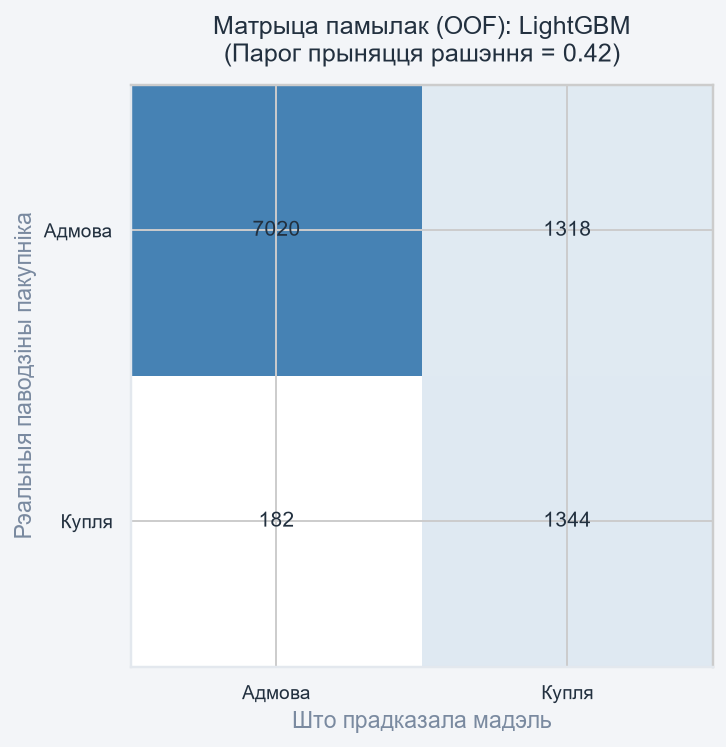

5

In [26]:
final_valid_name = [best_name]
final_configs = bench.prepare_final_models(best_name, optimized_results, final_valid_name)

opt_pr, opt_roc, opt_oof = bench.cross_validate_newV(split.x_cv, split.y_cv, models_conf=final_configs)

best_threshold, best_score = evaluator.optimize_threshold_for_fbeta(y_true=split.y_cv, oof_probas=opt_oof[best_name], model_name=best_name, beta=2.0)
        
df_opt_oof_report = evaluator.compile_performance_report(y_true=split.y_cv, probas_dict=opt_oof, threshold=best_threshold)

print(f"\n[Report] Метрыкі мадэлі пасля OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = {best_threshold :.4f}):")
print(df_opt_oof_report.to_string(index=False))

cm_path = viz.plot_classification_results(
        y_true=split.y_cv.to_numpy(), 
        y_probas=opt_oof[best_name], 
        model_name=best_name,
        threshold=best_threshold,  
        filename=f"CV_confusion_matrix_{best_name}.png"
    )
display(Image(filename=cm_path))

plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку    

## 7. Secure refit і Test


[Secure Refit] Старт навучання фінальнага пайплайна для LightGBM...
[Secure Refit] Навучанне мадэлі з Early Stopping...

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.410 (Валідацыйны F2: 0.7737)


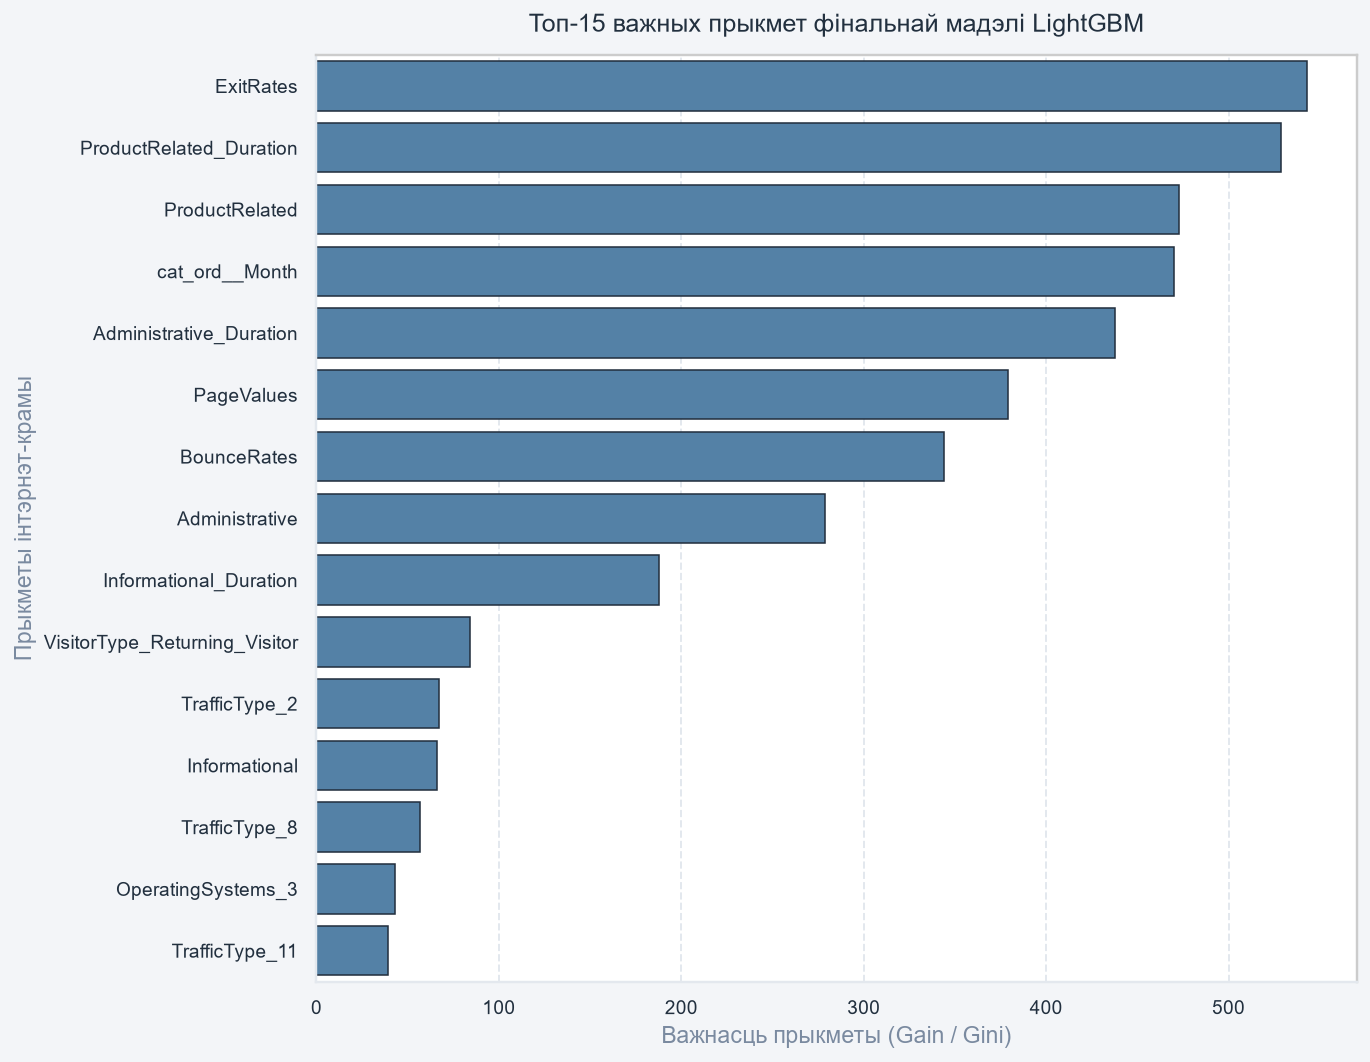

[Final Predict] Адзін чысты прагноз на тэсце з парогам 0.41...
                  Мадэль   PR-AUC  ROC-AUC  Precision  Recall       F1       F2  Accuracy
LightGBM (Фінальны тэст) 0.743151 0.931053   0.487518 0.86911 0.624647 0.751471    0.8382


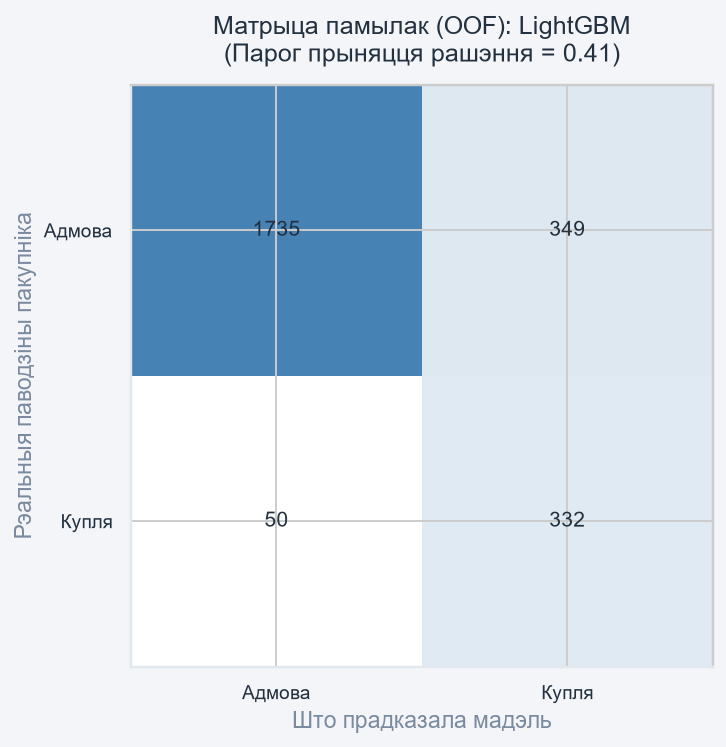

In [27]:
final_methods = [best_name]
final_configs = bench.prepare_final_models(
    best_name=best_name, 
    optimized_results=optimized_results, 
    models_to_keep=final_methods
)

# 2. Выклікаем фінальны refit, перадаючы ўжо гатовы слоўнік з мадэлямі
final_test_pipeline, best_threshold = bench.final_secure_refit(
    final_configs=final_configs,
    x_train=split.x_train,
    y_train=split.y_train,
    x_val=split.x_val,
    y_val=split.y_val,
    evaluator=evaluator
)

importance_path = viz.plot_final_feature_importance(
        model_pipeline=final_test_pipeline, 
        model_name=best_name, 
        filename=f"final_test_feature_importance_{best_name}.png"
    ) 
display(Image(filename=importance_path))

# Выхад на ТЭСТАВУЮ выбарку з гатовым парогам
test_proba, test_pred = bench.predict_with_final_threshold(
        trained_pipeline=final_test_pipeline,
        x_test=split.x_test,
        threshold=best_threshold
    )    
    
test_probas_dict = {f"{best_name} (Фінальны тэст)": test_proba}
df_final_test_report = evaluator.compile_performance_report(
    y_true=split.y_test,
    probas_dict=test_probas_dict,
    threshold=best_threshold
    )
print(df_final_test_report.to_string(index=False))

final_cm_path = viz.plot_classification_results(
    y_true=split.y_test.to_numpy(),
    y_probas=test_proba, model_name=best_name,
    threshold=best_threshold, filename=f"final_test_confusion_matrix_{best_name}.png"
    )
display(Image(filename=final_cm_path))


Высновы па выніках тэсціравання аптымізаванай мадэлі **LightGBM** на адкладзенай выбарцы (`split.x_test`).

* **Высокая здольнасць да абагульнення (Няма перанавучання):** 
* **Рабочага парог (0.410)**  дазволіў зафіксаваць высокую поўнату ахопу мэтавага класа (**Recall = 0.8691**), што азначае паспяховую ідэнтыфікацыю **86.91% рэальных пакупнікоў**.